In [2]:
import os
import echopype as ep
import matplotlib.pyplot as plt
import datetime
import numpy as np
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
#USE echopype_env on oceanica_joan folder!

#NOTES:
#.bot files for EK60 sonars are not used by echpype, not implemented
#dades de EK80?
#deadline fins després de sermana santa per jugar
# del 7 al 16 d'abril 

In [ ]:
#FileName = 'D20110113-T105327'
#FileName = 'D20110113-T105327'
#rawFileDate = datetime.datetime(int(FileName[1:5]), int(FileName[5:7]), int(FileName[7:9]))
#dates = ['D20110113-T', 'D20110112-T', 'D20110111-T', 'D20110110-T', 'D20110109-T', 'D20110108-T']
dates = ['D20110113-T', 'D20110112-T', 'D20110111-T']




In [ ]:
#transform all files to netcdf
for date in dates:
    FileNames = [
        f for f in os.listdir('../data/MALASPINA_LEG1/')
        if date in f and '.raw' in f]
    print('got file names')
    
    for FileName in FileNames:
        ed = ep.open_raw("../data/MALASPINA_LEG1/" + FileName, sonar_model="EK60")  # for EK60 file
        ed.to_netcdf("../data/MALASPINA_LEG1/netcdf/" + FileName + '.nc')

D20110110-T
got file names
getting netcdf files...
raw files transformed
combining data...
computing Sv...
add_depth...
remove_background_nouse...
adding location...
creating echogram...


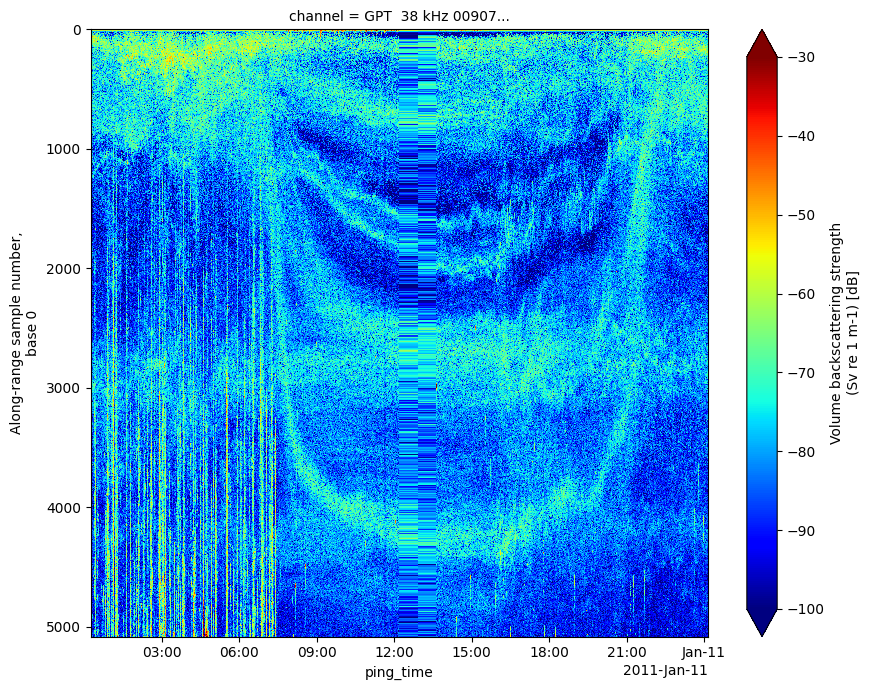

In [10]:
for date in dates:
    print(date)
    #extract raw file names for that date
    FileNames = [
        f for f in os.listdir('../data/MALASPINA_LEG1/')
        if date in f and '.raw' in f]
    print('got file names')
    
    #get a list of all the converted raw files into EchoData objects
    print('getting netcdf files...')
    ed_list = []
    for FileName in FileNames:
        ed = ep.open_converted("../data/MALASPINA_LEG1/netcdf/" + FileName + '.nc')
        ed_list.append(ed)
        del ed
    print('raw files transformed')
    
    #combine echodata converted for the same day and process for two outputs: echogram and coordinates
    print('combining data...')
    ed_cons = ep.combine_echodata(ed_list)
    print('computing Sv...')
    ed_Sv = ep.calibrate.compute_Sv(ed_cons)
    
    print('add_depth...')
    ed_Sv = ep.consolidate.add_depth(ed_Sv)
    print('remove_background_nouse...')
    ds_Sv = ep.clean.remove_background_noise(    # obtain a denoised Sv dataset
    ed_Sv,                # calibrated Sv dataset
    range_sample_num=30,  # number of samples along the range_sample dimension for estimating noise
    ping_num=5,           # number of pings for estimating noise
    )
    print('adding location...')
    ed_Sv = ep.consolidate.add_location(ds_Sv, ed_cons)
    ed_Sv[['latitude', 'longitude']].to_dataframe().to_csv('../data/coords/'+date+'.csv')
    print('creating echogram...')
    echogramPlot = ed_Sv["Sv"].sortby('ping_time').plot(
    x="ping_time",
    row="channel",
    figsize=(9, 7),
    vmin=-100, 
    vmax=-30,
    cmap="jet",
    )
    for ax in echogramPlot.axs.flatten():
        ax.invert_yaxis()
    echogramPlot.fig.savefig("../data/echograms/"+date+'.png', dpi=300, bbox_inches="tight")
    del echogramPlot, ed_cons, ed_Sv

combining data...
computing Sv...
add_depth...
remove_background_nouse...
adding location...
creating echogram...


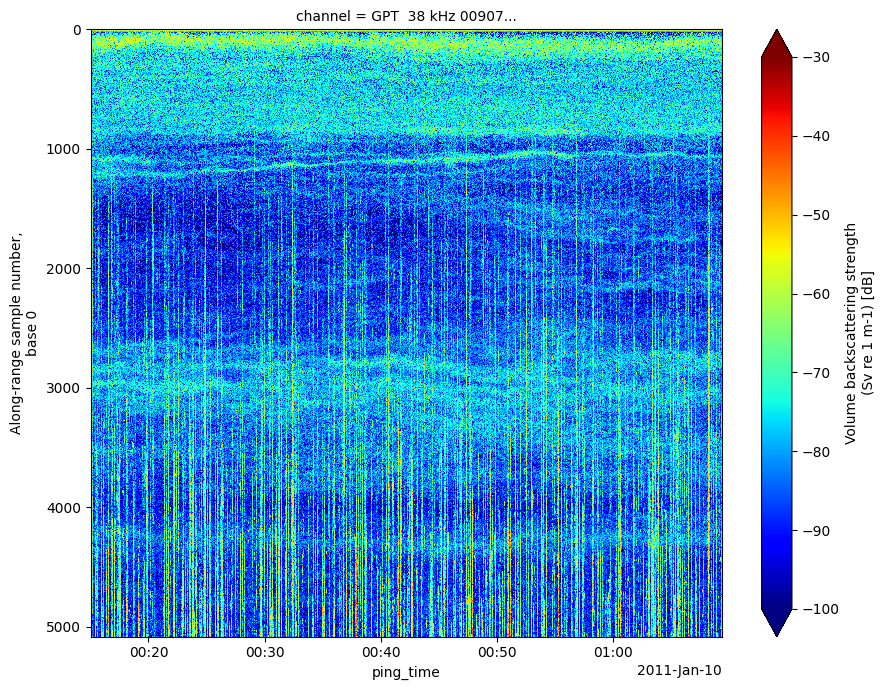

In [9]:
ed_list = []
FileNames = ['D20110110-T001502.raw', 'D20110110-T004210.raw']
for FileName in FileNames:
    ed = ep.open_converted("../data/MALASPINA_LEG1/netcdf/" + FileName + '.nc')
    ed_list.append(ed)
    del ed
#combine echodata converted for the same day and process for two outputs: echogram and coordinates
print('combining data...')
ed_cons = ep.combine_echodata(ed_list)
print('computing Sv...')
ed_Sv = ep.calibrate.compute_Sv(ed_cons)

print('add_depth...')
ed_Sv = ep.consolidate.add_depth(ed_Sv)
print('remove_background_nouse...')
ds_Sv = ep.clean.remove_background_noise(    # obtain a denoised Sv dataset
ed_Sv,                # calibrated Sv dataset
range_sample_num=30,  # number of samples along the range_sample dimension for estimating noise
ping_num=5,           # number of pings for estimating noise
)
print('adding location...')
ed_Sv = ep.consolidate.add_location(ds_Sv, ed_cons)
ed_Sv[['latitude', 'longitude']].to_dataframe().to_csv('../data/coords/'+date+'.csv')
print('creating echogram...')
echogramPlot = ed_Sv["Sv"].sortby('ping_time').plot(
x="ping_time",
row="channel",
figsize=(9, 7),
vmin=-100, 
vmax=-30,
cmap="jet",
)

for ax in echogramPlot.axs.flatten():
    ax.invert_yaxis()

echogramPlot.fig.savefig("../data/echograms/"+date+'.png', dpi=300, bbox_inches="tight")
del echogramPlot, ed_cons, ed_Sv

In [87]:
ed_Sv = ep.consolidate.add_location(ed_Sv, ed_cons)

In [82]:
ed_Sv[['latitude', 'longitude']].to_dataframe().to_csv('../data/coords/'+date+'.csv')


MemoryError: Unable to allocate 1.08 GiB for an array with shape (5083, 28552) and data type float64

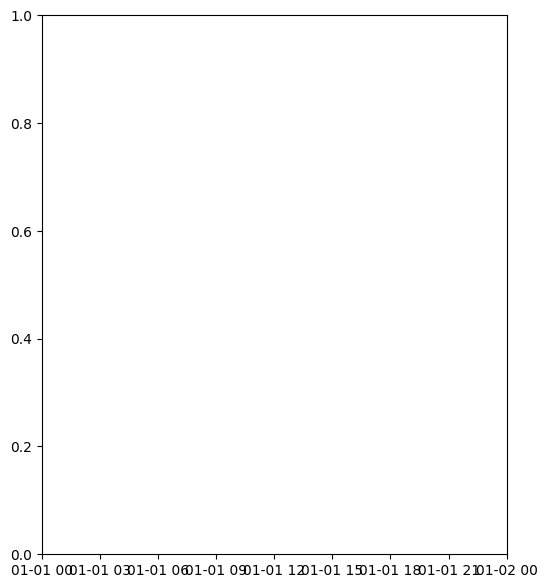

In [98]:
echogramPlot = ed_Sv["Sv"].sortby('ping_time').plot(
    x="ping_time",
    row="channel",
    figsize=(6, 7),
    vmin=-100, 
    vmax=-30,
    cmap="jet",
)

In [96]:
echogramPlot.fig.savefig("../data/echograms/"+date+'.png', dpi=300, bbox_inches="tight")

In [ ]:
ed_Sv = ep.consolidate.add_depth(ed_Sv)

In [37]:
ed_Sv.water_level

<xarray.DataArray 'water_level' ()> Size: 8B
array(4.5)
Attributes:
    long_name:  Distance from the platform coordinate system origin to the no...
    units:      m

In [52]:
bin_size = 1537.07958984 * 0.000256 / 2 #sound speed (m/s) and sample interval (s) = m/bin

c = float(ed["Environment"]["sound_speed_indicative"].values[0, 0])

dt = float(ed["Sonar/Beam_group1"]["sample_interval"].values[0, 0])

transducer_depth = 4.5 #ed_Sv.water_level --> profunditat del transductor respecte la superfície
nbins = ed_Sv.dims["range_sample"]

range_real = (np.arange(nbins) * dt * c) / 2
range_real

depth_real = range_real + transducer_depth
depth_real

ed_Sv = ed_Sv.assign(
    depth_real=("range_sample", depth_real)
)



C:\Users\jsala\AppData\Local\Temp\ipykernel_17572\3556581901.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nbins = ed_Sv.dims["range_sample"]


array([0.00000000e+00, 1.96746187e-01, 3.93492374e-01, ...,
       9.99470630e+02, 9.99667376e+02, 9.99864122e+02], shape=(5083,))

array([   4.5       ,    4.69674619,    4.89349237, ..., 1003.97062998,
       1004.16737616, 1004.36412235], shape=(5083,))

In [50]:
Sv = ed_Sv["Sv"].isel(channel=0)

bottom_idx = Sv.argmax("range_sample")   # aproximació simple
bottom_depth = depth_real[bottom_idx]
bottom_depth.max()

np.float64(1003.1836452285662)

In [53]:
Sv_lin = 10 ** (Sv / 10)
bottom_idx = Sv_lin.argmax(dim="range_sample")
depth_bottom = ed_Sv["depth_real"][bottom_idx]

In [55]:
depth_bottom = ed_Sv["depth_real"][bottom_idx]
depth_bottom

<xarray.DataArray 'depth_real' (ping_time: 116)> Size: 928B
array([ 977.40989473,  934.51922596,  904.22031317,  871.16695375,
        590.21339871,  802.89602686,  772.59711406,  988.23093502,
        960.29297646,  926.84612467,  906.38452122,  874.51163893,
        842.83550282,  815.09429045,    5.09023856,  998.46173674,
        969.93353963,    5.09023856,  905.2040441 ,  881.20100929,
        851.09884268,  818.43897563,  785.5823624 ,  772.40036787,
        483.57696535,  944.5532815 ,  911.69666827,  883.9554559 ,
        850.50860411,  577.22815037,  794.63268701,  761.57932759,
        980.36108754,  945.34026625,  952.61987517,  985.4764884 ,
        758.62813478,  758.62813478,  740.92097795,  962.45718452,
        954.98082941,  723.21382112,  740.52748558,  989.21466595,
        985.67323459,  968.94980869,  713.17976559,  983.50902653,
        753.11924155, 1001.41292955,  981.14807228,  956.7515451 ,
        958.91575315,  984.29601128, 1002.19991429,  503.05483787,
        975.83592524,  951.63614423,  957.53852984,  983.50902653,
        757.84115004, 1000.82269098,  993.54308207,  968.35957013,
        952.81662136,  968.55631632,  993.14958969,  757.05416529,
        996.1007825 ,  971.31076293,  955.57106797,  723.80405968,
          5.09023856,  885.92291777,  812.14309765,  781.84418485,
        745.83963263,    5.09023856,  984.68950365,    5.09023856,
          5.09023856,  817.65199088,  990.59188926,  934.32247978,
        968.94980869,  836.93311721,  905.2040441 ,  878.05307029,
          5.09023856,  961.67019977,  937.66716496,  932.55176409,
        781.84418485,  890.64482626,  850.31185793,  766.89147464,
        762.36631234,    5.09023856,  889.07085677,  945.34026625,
        901.46586655,  869.98647663,  837.1298634 ,  806.8309506 ,
        773.580845  ,  989.80490451,  709.83508041,  922.51770856,
        648.05677769,  868.21576094,  842.83550282,  818.24222945,
        538.27240534, 1003.18364523,  969.34330106,  935.69970309])
Coordinates:
  * ping_time     (ping_time) datetime64[ns] 928B 2011-01-13T10:53:27.695963 ...
    range_sample  (ping_time) int64 928B 4945 4727 4573 4405 ... 5076 4904 4733
    channel       <U34 136B 'GPT  38 kHz 009072055bb4 1-1 ES38B'

In [33]:
ed["Sonar/Beam_group1"]['sample_interval']
ed["Environment"]['sound_speed_indicative']
ed["Sonar/Beam_group1"]['range_sample']
ed["Environment"]['water_level']

<xarray.DataArray 'sample_interval' (channel: 1, ping_time: 116)> Size: 928B
array([[0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256, 0.000256, 0.000256, 0.000256, 0.000256,
        0.000256, 0.000256]])
Coordinates:
  * channel    (channel) <U34 136B 'GPT  38 kHz 009072055bb4 1-1 ES38B'
  * ping_time  (ping_time) datetime64[ns] 928B 2011-01-13T10:53:27.695963 ......
Attributes:
    long_name:  Interval between recorded raw data samples
    units:      s
    valid_min:  0.0

<xarray.DataArray 'sound_speed_indicative' (channel: 1, time1: 116)> Size: 928B
array([[1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984]])
Coordinates:
  * channel  (channel) <U34 136B 'GPT  38 kHz 009072055bb4 1-1 ES38B'
  * time1    (time1) datetime64[ns] 928B 2011-01-13T10:53:27.695963 ... 2011-...
Attributes:
    long_name:      Indicative sound speed
    standard_name:  speed_of_sound_in_sea_water
    units:          m/s
    valid_min:      0.0

<xarray.DataArray 'range_sample' (range_sample: 5083)> Size: 41kB
array([   0,    1,    2, ..., 5080, 5081, 5082], shape=(5083,))
Coordinates:
  * range_sample  (range_sample) int64 41kB 0 1 2 3 4 ... 5079 5080 5081 5082
Attributes:
    long_name:  Along-range sample number, base 0

KeyError: "No variable named 'water_level'. Variables on the dataset include ['absorption_indicative', 'sound_speed_indicative', 'frequency_nominal', 'channel', 'time1']"

In [26]:
(ed["Environment"]["sound_speed_indicative"].values)


array([[1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958984, 1537.07958984,
        1537.07958984, 1537.07958984, 1537.07958

In [19]:
type(ed_Sv['depth'])
ed_Sv.water_level
ed["Environment"]["sample_interval"]

xarray.core.dataarray.DataArray

<xarray.DataArray 'water_level' ()> Size: 8B
array(4.5)
Attributes:
    long_name:  Distance from the platform coordinate system origin to the no...
    units:      m

KeyError: "No variable named 'sample_interval'. Variables on the dataset include ['absorption_indicative', 'sound_speed_indicative', 'frequency_nominal', 'channel', 'time1']"

<Figure size 1400x600 with 0 Axes>

Text(0.5, 0, 'Ping time')

Text(0, 0.5, 'True depth (m)')

Text(0.5, 1.0, 'EK60 Echogram — True Depth (slant range + draft correction)')

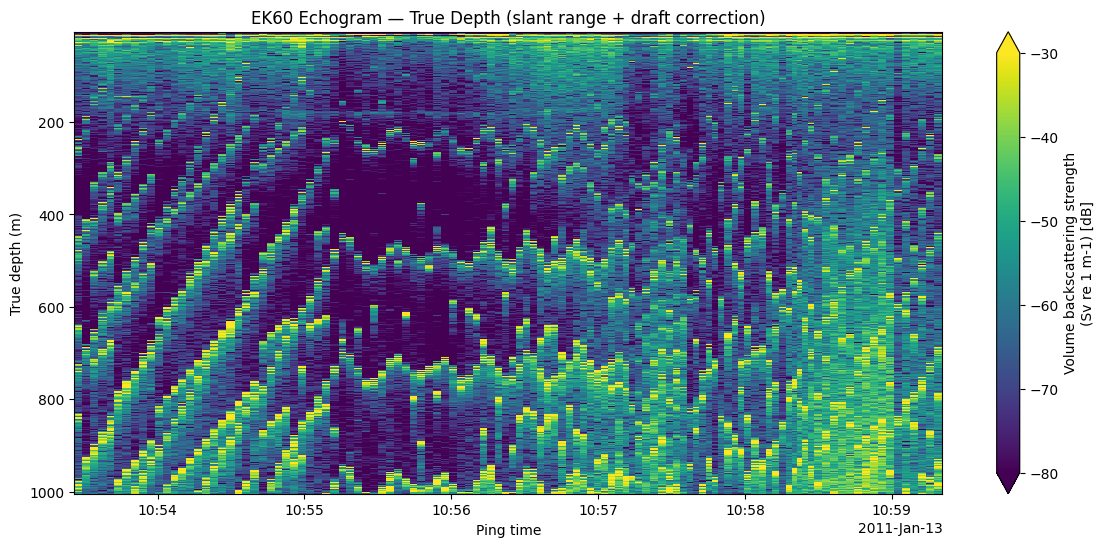

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

channel = ed_Sv.channel.values[0]

# Extract Sv and echo_range
sv = ed_Sv.Sv.sel(channel=channel)
echo_range = ed_Sv.echo_range.sel(channel=channel)

# Draft / transducer depth
draft = float(ed_Sv.water_level.values)   # = 4.5 m

# Compute true depth
true_depth = echo_range + draft

# Align arrays
sv, true_depth = xr.align(sv, true_depth)

# Attach true depth as coordinate
sv = sv.assign_coords(depth=true_depth)

# Plot
plt.figure(figsize=(14,6))
sv.plot(
    x="ping_time",
    y="depth",
    vmin=-80, vmax=-30,
    cmap="viridis"
)
plt.gca().invert_yaxis()
plt.xlabel("Ping time")
plt.ylabel("True depth (m)")
plt.title("EK60 Echogram — True Depth (slant range + draft correction)")
plt.show()


In [57]:
print(ed["Platform"].data_vars)

Data variables:
    latitude             (time1) float64 3kB -22.89 -22.89 ... -22.9 -22.9
    longitude            (time1) float64 3kB -43.2 -43.2 -43.2 ... -43.21 -43.21
    sentence_type        (time1) <U3 4kB 'GGA' 'GGA' 'GGA' ... 'GGA' 'GGA' 'GGA'
    pitch                (time2) float64 928B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    roll                 (time2) float64 928B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    vertical_offset      (time2) float64 928B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    water_level          float64 8B 4.5
    MRU_offset_x         float64 8B nan
    MRU_offset_y         float64 8B nan
    MRU_offset_z         float64 8B nan
    MRU_rotation_x       float64 8B nan
    MRU_rotation_y       float64 8B nan
    MRU_rotation_z       float64 8B nan
    position_offset_x    float64 8B nan
    position_offset_y    float64 8B nan
    position_offset_z    float64 8B nan
    transducer_offset_x  (channel) float64 8B 0.0
    transducer_offset_y  (channel) float64 8B 0.0
    transduce

In [54]:
import pandas as pd
lat = ed["Platform"]["latitude"].values
lon = ed["Platform"]["longitude"].values
time = ed["Platform"]["time1"].values

df = pd.DataFrame({
    "time": time,
    "latitude": lat,
    "longitude": lon
})

df.to_csv('coords_' + FileName +'.csv')


In [162]:
import struct
import numpy as np
from datetime import datetime, timedelta

FILETIME_EPOCH = datetime(1601, 1, 1)

def filetime_to_datetime(filetime_int):
    """Convert 64-bit Windows FILETIME to Python datetime."""
    return FILETIME_EPOCH + timedelta(microseconds=filetime_int / 10)

def parse_ek60_bot(botfile):
    RECORD = 848
    BLOCK = 28  # Correct BOT0 block size
    TAG = b'BOT0'
    
    times = []
    depths = []
    
    with open(botfile, "rb") as f:
        f.read(RECORD)  # skip header
        
        while True:
            rec = f.read(RECORD)
            if len(rec) < RECORD:
                break
            
            for pos in range(0, RECORD - BLOCK, 1):  # scan byte-by-byte
                if rec[pos+4:pos+8] == TAG:
                    
                    # timestamp (uint64)
                    ts_raw = struct.unpack('<Q', rec[pos+8:pos+16])[0]
                    ts = filetime_to_datetime(ts_raw)
                    
                    # depth (float64)
                    depth = struct.unpack('<d', rec[pos+20:pos+28])[0]
                    
                    times.append(ts)
                    depths.append(depth)
    
    return np.array(times), np.array(depths)

times, bottom = parse_ek60_bot("../data/MALASPINA_LEG1/" + FileName +".bot")

print(times[:5])
print(bottom[:5])



[datetime.datetime(2011, 1, 13, 10, 53, 27, 695962)
 datetime.datetime(2011, 1, 13, 10, 53, 30, 984608)
 datetime.datetime(2011, 1, 13, 10, 53, 34, 257668)
 datetime.datetime(2011, 1, 13, 10, 53, 37, 530728)
 datetime.datetime(2011, 1, 13, 10, 53, 40, 803788)]
[0. 0. 0. 0. 0.]


<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Time')

Text(0, 0.5, 'Depth (m)')

Text(0.5, 1.0, 'Echogram with depth from echopype.add_depth()')

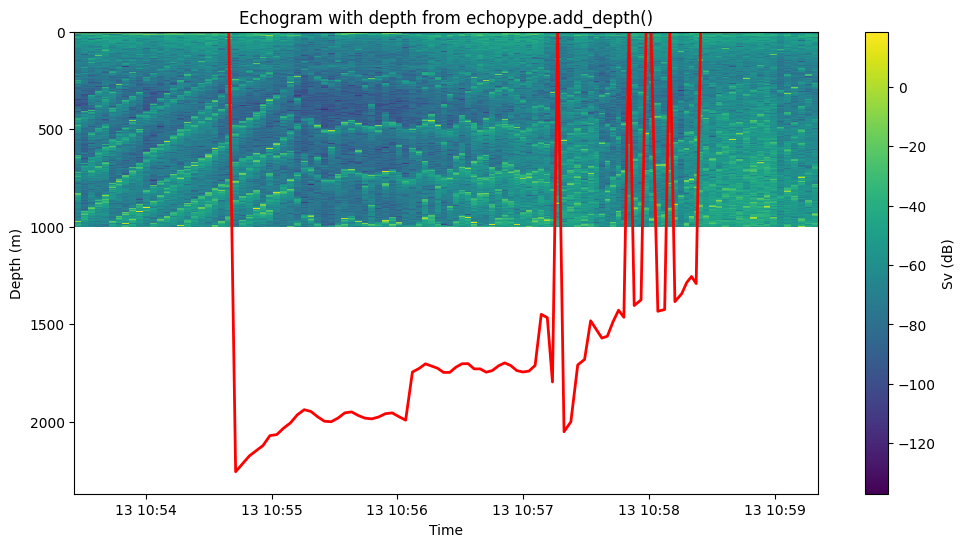

In [163]:
plt.figure(figsize=(12,6))
plt.pcolormesh(
    ed_Sv['ping_time'],
    depth,
    Sv_data.T,            # (range_sample, ping_time) .T is transposing array dimensions
    cmap="viridis",
    shading="auto"
)
plt.plot(times, bottom, "r-", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Time")
plt.ylabel("Depth (m)")
plt.colorbar(label="Sv (dB)")
plt.title("Echogram with depth from echopype.add_depth()")
plt.show()

KeyError: "No variable named 'Platform'. Variables on the dataset include ['channel', 'ping_time', 'range_sample', 'Sv', 'echo_range', ..., 'beamwidth_athwartship', 'source_filenames', 'filenames', 'water_level', 'depth']"